<a href="https://colab.research.google.com/github/nahmxp/rl-for-data-scientists/blob/main/notebooks/chapter_02_prerequisites/02_probability_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Prerequisites: Probability for RL## Concept Notebook[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)**No GPU required. Runtime: ~15 minutes.**This notebook covers the probability foundations used throughout the book: conditional probability, expectation, exploration as sampling, and the connection between probability distributions and RL policies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
print('Ready')

Ready


This cell imports necessary libraries: `numpy` for numerical operations, `matplotlib.pyplot` for plotting, and `scipy.stats` for statistical functions, particularly for working with probability distributions. The `print('Ready')` statement confirms that the libraries have been loaded successfully and the environment is set up.

## 2.1 Expected Value — The Foundation of RL ObjectivesEvery RL objective is an expectation. `E[R]` = average reward over many episodes. Understanding expectation is the first step.

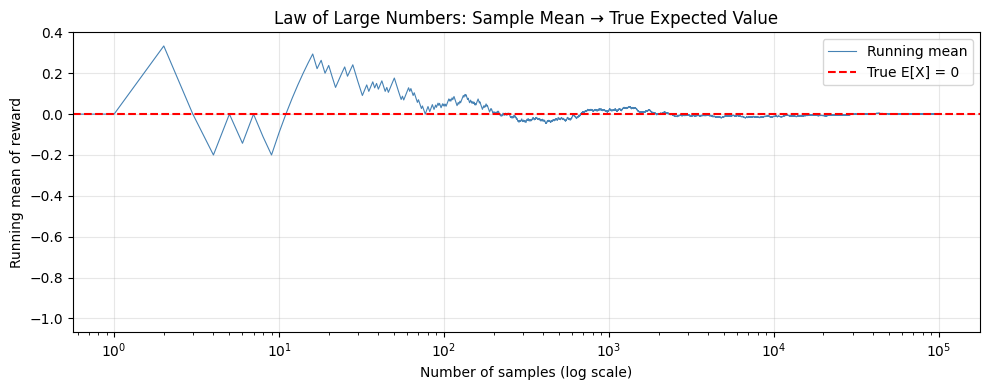

In [2]:
# Simulate expected value convergence
np.random.seed(42)
rng = np.random.default_rng(42)

# Coin flip: +1 for heads, -1 for tails. E[X] = 0
nsamples = [10, 100, 1000, 10000, 100000]
flips = rng.choice([-1, 1], size=100000)

fig, ax = plt.subplots(figsize=(10, 4))
running_mean = np.cumsum(flips) / np.arange(1, len(flips)+1)
ax.plot(running_mean, color='steelblue', linewidth=0.8, label='Running mean')
ax.axhline(0, color='red', linestyle='--', label='True E[X] = 0')
ax.set_xscale('log')
ax.set_xlabel('Number of samples (log scale)')
ax.set_ylabel('Running mean of reward')
ax.set_title('Law of Large Numbers: Sample Mean → True Expected Value')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This code block simulates the Law of Large Numbers using a coin flip experiment. It demonstrates how the sample mean of a random variable converges to its true expected value as the number of samples increases.

- `np.random.seed(42)` and `rng = np.random.default_rng(42)`: Set a random seed for reproducibility.
- `flips`: Generates 100,000 coin flips, where +1 represents heads and -1 represents tails. The true expected value (E[X]) for a fair coin is 0.
- `running_mean`: Calculates the cumulative mean of the flips, showing how the average changes with more samples.
- The plot visualizes this convergence, with the x-axis on a logarithmic scale to better show the initial fluctuations and eventual stabilization around the true expected value of 0.

## 2.2 The Gaussian Distribution as a PolicyA Gaussian (normal) distribution over actions is a continuous action-space policy. Mean = preferred action, std = exploration width.

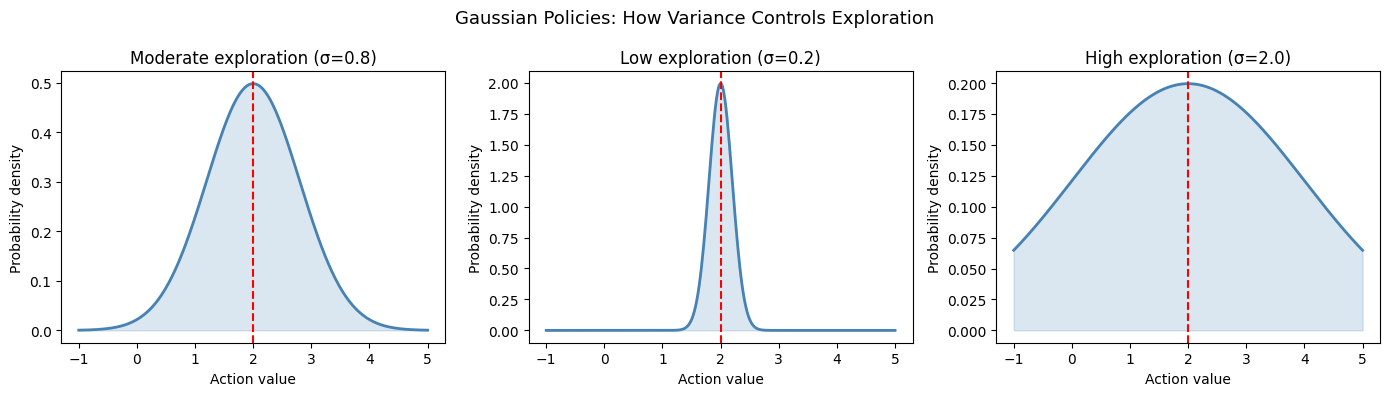

In [3]:
mu, sigma = 2.0, 0.8  # policy parameters
actions = np.linspace(-1, 5, 300)
probs = stats.norm.pdf(actions, mu, sigma)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (m, s, label) in zip(axes, [
    (2.0, 0.8, 'Moderate exploration (σ=0.8)'),
    (2.0, 0.2, 'Low exploration (σ=0.2)'),
    (2.0, 2.0, 'High exploration (σ=2.0)'),
]):
    ax.plot(actions, stats.norm.pdf(actions, m, s), color='steelblue', linewidth=2)
    ax.axvline(m, color='red', linestyle='--', label=f'μ={m}')
    ax.fill_between(actions, stats.norm.pdf(actions, m, s), alpha=0.2, color='steelblue')
    ax.set_title(label)
    ax.set_xlabel('Action value')
    ax.set_ylabel('Probability density')
plt.suptitle('Gaussian Policies: How Variance Controls Exploration', fontsize=13)
plt.tight_layout()
plt.show()

This cell illustrates how a Gaussian (normal) distribution can serve as a policy in continuous action spaces, particularly in Reinforcement Learning.

- `mu, sigma`: These are the policy parameters, where `mu` (mean) represents the preferred action and `sigma` (standard deviation) controls the exploration width.
- `actions`: Defines a range of possible action values.
- `probs`: Calculates the probability density function (PDF) for a Gaussian distribution.
- The three subplots demonstrate different exploration behaviors by varying the standard deviation (`sigma`):
  - **Moderate exploration**: A typical spread around the mean.
  - **Low exploration**: A narrow distribution, meaning the policy is more confident about the preferred action and explores less.
  - **High exploration**: A wide distribution, indicating more uncertainty and a broader exploration of possible actions.

This visualization helps understand how `sigma` directly impacts the agent's tendency to explore around its mean action.

## 2.3 Conditional Probability and the Markov PropertyThe Markov property says: `P(s_{t+1} | s_t, a_t, s_{t-1}, ...) = P(s_{t+1} | s_t, a_t)`The future depends only on the current state, not the full history. This is the mathematical foundation for MDPs.

In [4]:
# Visualise the Markov property with a simple chain
import numpy as np

# State transition matrix (3 states: Rainy, Cloudy, Sunny)
P = np.array([
    [0.7, 0.2, 0.1],  # From Rainy: stays Rainy 70%, goes Cloudy 20%, Sunny 10%
    [0.3, 0.4, 0.3],  # From Cloudy
    [0.2, 0.3, 0.5],  # From Sunny
])
states = ['Rainy', 'Cloudy', 'Sunny']

# Simulate a 20-step chain
current = 0  # start Rainy
chain = [states[current]]
for _ in range(20):
    current = np.random.choice(3, p=P[current])
    chain.append(states[current])

print('20-step Markov chain:', ' → '.join(chain[:10]), '...')
print('\nKey insight: the next state depends ONLY on the current state.')
print('P(Sunny tomorrow | Rainy today, Sunny last week) = P(Sunny tomorrow | Rainy today)')

20-step Markov chain: Rainy → Rainy → Sunny → Sunny → Sunny → Rainy → Rainy → Rainy → Cloudy → Cloudy ...

Key insight: the next state depends ONLY on the current state.
P(Sunny tomorrow | Rainy today, Sunny last week) = P(Sunny tomorrow | Rainy today)


This code demonstrates the Markov property, a fundamental concept in Reinforcement Learning and Markov Decision Processes (MDPs).

- `P`: Represents the state transition matrix for a simple weather system with three states: Rainy, Cloudy, and Sunny. Each row specifies the probabilities of transitioning to other states from the current state (e.g., from Rainy, there's a 70% chance of staying Rainy).
- `states`: A list of the defined weather states.
- The code then simulates a 20-step Markov chain, starting from a 'Rainy' state. In each step, the next state is chosen probabilistically based *only* on the current state's transition probabilities.
- The printed output shows a sequence of states, illustrating that the history (e.g., 'Sunny last week') does not influence the next state if the current state is known. The 'Key insight' explains this principle: the future state depends only on the present state, not on the entire past sequence of states.